In [9]:
import pandas as pd
import matplotlib.pyplot as plt

https://open-meteo.com/en/docs/historical-weather-api?start_date=2025-01-01&end_date=2025-12-31&timezone=America%2FNew_York&longitude=-73.9712&latitude=40.6782&hourly=temperature_2m,precipitation,rain,snowfall,snow_depth,wind_speed_10m,soil_temperature_0_to_7cm,relative_humidity_2m,dew_point_2m,apparent_temperature,wind_gusts_10m,wind_direction_10m&daily=sunrise,sunset,precipitation_sum,rain_sum,wind_speed_10m_max,wind_gusts_10m_max,snowfall_sum,precipitation_hours,daylight_duration,weather_code,temperature_2m_mean,temperature_2m_min,temperature_2m_max,apparent_temperature_mean,apparent_temperature_min,apparent_temperature_max&temperature_unit=fahrenheit&wind_speed_unit=mph&precipitation_unit=inch&location_mode=csv_coordinates&csv_coordinates=40.7831,+-73.9712%0A40.6782,+-73.9442%0A40.7769,+-73.8740%0A40.8448,+-73.8648%0A40.5795,+-74.1502#api_response

location_id,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation
0,40.808434,-74.0199,43.0,-14400,America/New_York,GMT-4
1,40.667835,-73.93768,23.0,-14400,America/New_York,GMT-4
2,40.808434,-73.89206,1.0,-14400,America/New_York,GMT-4
3,40.878735,-73.86914,15.0,-14400,America/New_York,GMT-4
4,40.597538,-74.08771,41.0,-14400,America/New_York,GMT-4


In [14]:
df = pd.read_csv("nyc2025weatherdata.csv")
df.head()

,location_id,time,temperature_2m (°F),precipitation (inch),rain (inch),snowfall (inch),snow_depth (ft),wind_speed_10m (mp/h),soil_temperature_0_to_7cm (°F),soil_temperature_7_to_28cm (°F),relative_humidity_2m (%),dew_point_2m (°F),apparent_temperature (°F),wind_gusts_10m (mp/h),wind_direction_10m (°)
0,0,2025-01-01T00:00,45.6,0.146,0.146,0.0,0.0,10.7,44.3,43.7,94,44.0,39.5,22.4,91
1,0,2025-01-01T01:00,46.8,0.035,0.035,0.0,0.0,9.3,44.6,43.7,96,45.8,41.8,23.7,92
2,0,2025-01-01T02:00,47.6,0.000,0.000,0.0,0.0,4.8,45.0,43.7,97,46.7,44.7,18.1,109
3,0,2025-01-01T03:00,48.0,0.000,0.000,0.0,0.0,5.4,45.3,43.8,99,47.7,45.1,10.1,171
4,0,2025-01-01T04:00,48.0,0.000,0.000,0.0,0.0,5.5,45.7,43.9,98,47.6,45.1,10.3,223


In [23]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 43800 entries, 0 to 43799
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   location_id                      43800 non-null  int64         
 1   time                             43800 non-null  datetime64[us]
 2   temperature_2m (°F)              43800 non-null  float64       
 3   precipitation (inch)             43800 non-null  float64       
 4   rain (inch)                      43800 non-null  float64       
 5   snowfall (inch)                  43800 non-null  float64       
 6   snow_depth (ft)                  43800 non-null  float64       
 7   wind_speed_10m (mp/h)            43800 non-null  float64       
 8   soil_temperature_0_to_7cm (°F)   43800 non-null  float64       
 9   soil_temperature_7_to_28cm (°F)  43800 non-null  float64       
 10  relative_humidity_2m (%)         43800 non-null  int64         
 11  

In [24]:
print(df.describe())

       location_id                 time  temperature_2m (°F)  \
count  43800.00000                43800         43800.000000   
mean       2.00000  2025-07-02 11:30:00            54.605893   
min        0.00000  2025-01-01 00:00:00             1.900000   
25%        1.00000  2025-04-02 05:45:00            38.900000   
50%        2.00000  2025-07-02 11:30:00            55.800000   
75%        3.00000  2025-10-01 17:15:00            69.900000   
max        4.00000  2025-12-31 23:00:00           105.200000   
std        1.41423                  NaN            18.883046   

       precipitation (inch)   rain (inch)  snowfall (inch)  snow_depth (ft)  \
count          43800.000000  43800.000000     43800.000000     43800.000000   
mean               0.004886      0.004571         0.002199         0.016665   
min                0.000000      0.000000         0.000000         0.000000   
25%                0.000000      0.000000         0.000000         0.000000   
50%                0.000000 

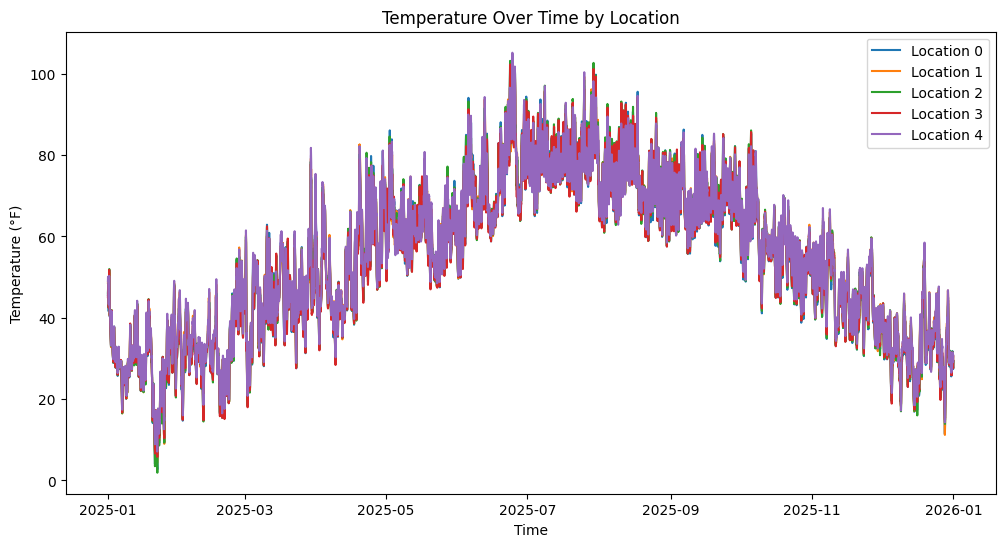

In [15]:

df["time"] = pd.to_datetime(df["time"])

plt.figure(figsize=(12,6))

for loc in df["location_id"].unique():
    subset = df[df["location_id"] == loc]
    plt.plot(subset["time"], subset["temperature_2m (°F)"], label=f"Location {loc}")

plt.xlabel("Time")
plt.ylabel("Temperature (°F)")
plt.title("Temperature Over Time by Location")
plt.legend()
plt.show()

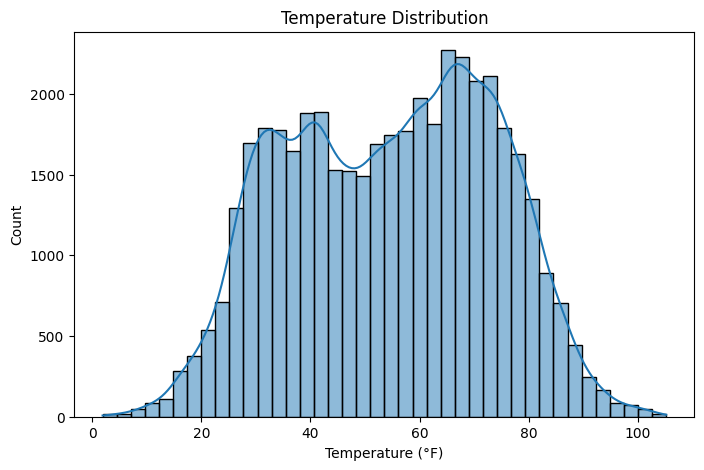

In [16]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["temperature_2m (°F)"], bins=40, kde=True)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°F)")
plt.show()

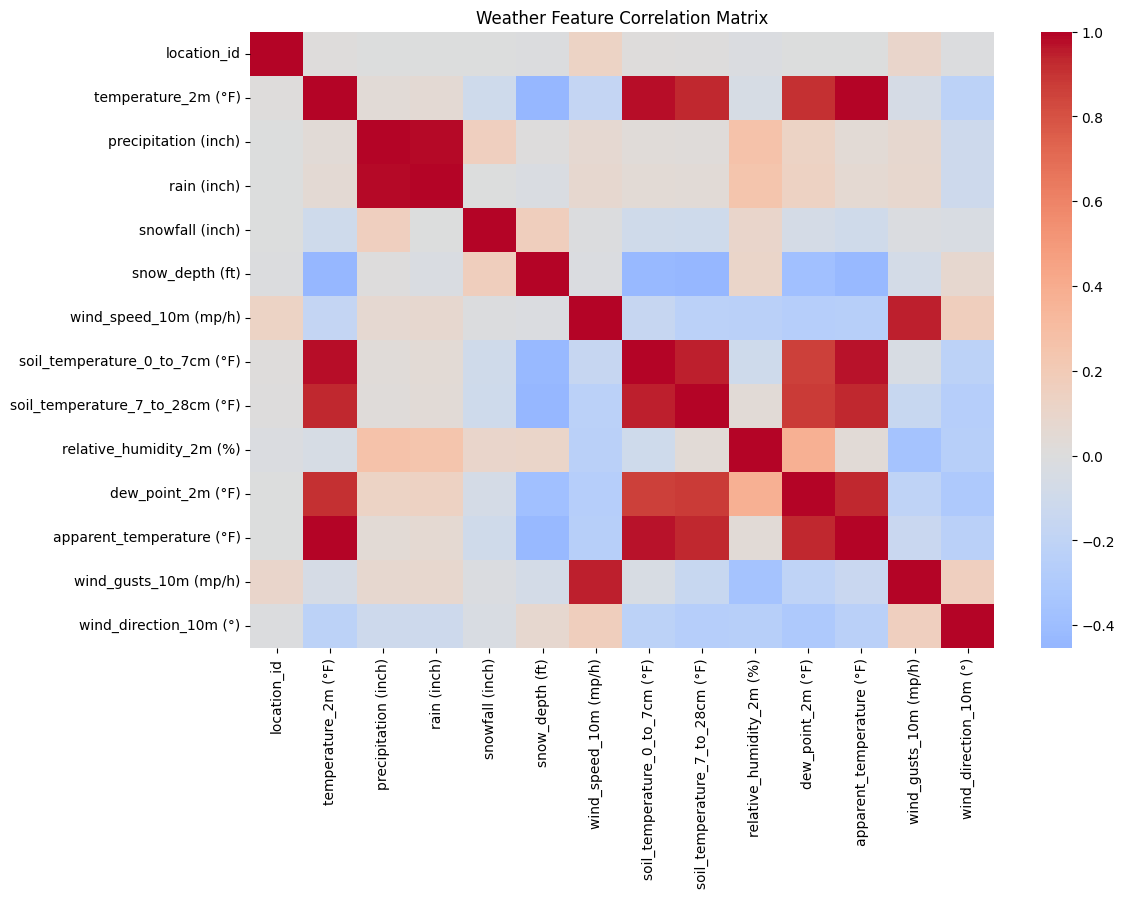

In [17]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)

plt.title("Weather Feature Correlation Matrix")
plt.show()

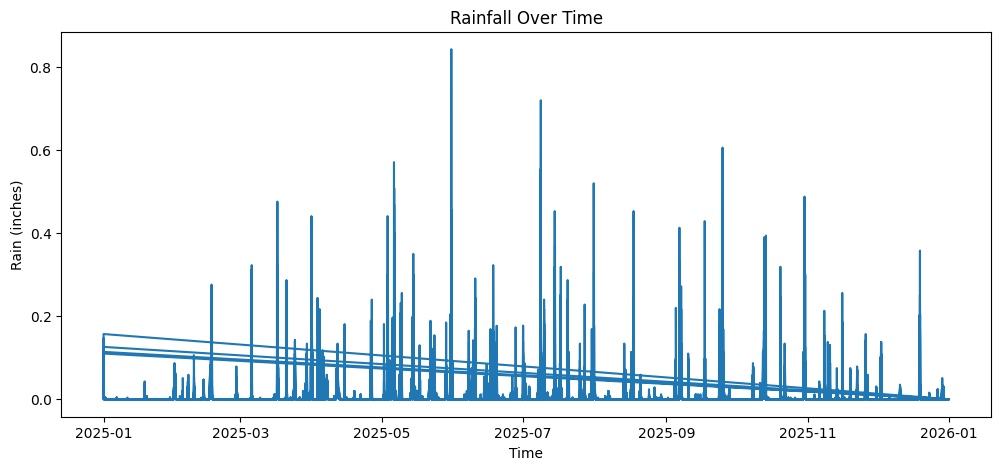

In [18]:
plt.figure(figsize=(12,5))

plt.plot(df["time"], df["rain (inch)"])

plt.title("Rainfall Over Time")
plt.xlabel("Time")
plt.ylabel("Rain (inches)")
plt.show()